# 크리깅 강건 최적화 파이프라인 데모 (합성 데이터)

`Kriging_bumper_SEA.ipynb`는 실제 카티아/아바쿠스 데이터가 있어야 돌아가는 TODO 골격이라, 지금 당장은 실행해서 확인할 수 없음. 이 노트북은 **실제 SEA 대신 가상의 함수**로 같은 파이프라인(DOE → 서로게이트 → 강건 목적함수 → 최적화)을 처음부터 끝까지 돌려서, 코드 자체가 제대로 동작하는지, 특히 강건성 가중치 κ를 올리면 최적 설계가 실제로 바뀌는지를 검증하는 용도.

**주의**: 아래 `synthetic_sea` 함수는 실제 범퍼 물리를 나타내지 않는 가상의 함수. 다만 "두께가 두꺼울수록 충돌 각도 변화에 덜 민감해진다"는 정성적 경향만 흉내내서, 강건 설계에서 기대할 수 있는 트레이드오프(평균 성능 vs 안정성)를 보여주도록 만듦.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import qmc
from scipy.optimize import minimize
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.model_selection import KFold, cross_val_score

# ---- Kriging_bumper_SEA.ipynb와 동일한 유틸 함수 ----

def theoretical_scale(x, domain_min, domain_max, target_min=-1, target_max=1):
    x_std = (x - domain_min) / (domain_max - domain_min)
    return x_std * (target_max - target_min) + target_min


def inverse_theoretical_scale(x_scaled, domain_min, domain_max, target_min=-1, target_max=1):
    # 스케일링된 [-1,1] 공간의 값을 물리 단위로 되돌림 (최적화 결과 해석용)
    x_std = (x_scaled - target_min) / (target_max - target_min)
    return x_std * (domain_max - domain_min) + domain_min


def lhs_design(domain_min, domain_max, n_samples, seed=0):
    dim = domain_min.shape[0]
    sampler = qmc.LatinHypercube(d=dim, seed=seed)
    unit_samples = sampler.random(n=n_samples)
    lo = domain_min.ravel()
    hi = domain_max.ravel()
    physical = lo + unit_samples * (hi - lo)
    return physical.T  # (dim, n_samples)

## 1. DOE 생성 및 시각화

설계변수 2개(두께 `t`, 높이 `h`), 불확실 변수 2개(충돌각 편차 `theta`, 재료 물성 배율 `E`)로 4차원 DOE를 LHS로 생성. 두 설계변수만 산점도로 찍어서 공간이 고르게 채워지는지 눈으로 확인.

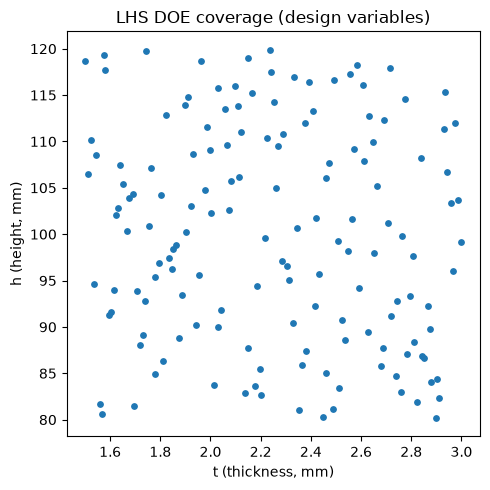

In [2]:
# 변수 순서: [t(두께, mm), h(높이, mm), theta(충돌각 편차, deg), E(재료 물성 배율)]
domain_min = np.array([[1.5], [80.0], [-15.0], [0.98]])
domain_max = np.array([[3.0], [120.0], [15.0], [1.02]])

DESIGN_IDX = [0, 1]  # t, h — 최적화 대상
NOISE_IDX = [2, 3]   # theta, E — 불확실성 변수

n_train = 150
X_train_phys = lhs_design(domain_min, domain_max, n_train, seed=0)

plt.figure(figsize=(5, 5))
plt.scatter(X_train_phys[0], X_train_phys[1], s=15)
plt.xlabel('t (thickness, mm)')
plt.ylabel('h (height, mm)')
plt.title('LHS DOE coverage (design variables)')
plt.tight_layout()
plt.savefig('doe_coverage.png', dpi=120)
plt.show()

## 2. 합성 SEA 함수로 데이터 생성 (실제로는 아바쿠스 결과가 들어갈 자리)

`t=2.0mm` 근처에서 평균 SEA가 최대가 되지만, 두께가 얇을수록 충돌각 변화(`theta`)에 더 민감해지도록(분산이 커지도록) 구성. 즉 "평균은 t=2.0 근처가 제일 좋지만, 안정성까지 고려하면 좀 더 두꺼운 쪽이 유리할 수 있다"는 상황을 흉내냄.

In [3]:
def synthetic_sea(t, h, theta_deg, E, t0=2.0, a=1.0, c=0.15, k=8.0):
    theta_rad = np.deg2rad(theta_deg)
    base = (a - c * (t - t0) ** 2) * (100.0 / h) ** 0.5
    angle_penalty = (k / t) * theta_rad ** 2
    return base * E - angle_penalty


Y_train = synthetic_sea(*X_train_phys)

n_test = 1000
rng = np.random.default_rng(1)
X_test_phys = domain_min + rng.uniform(0, 1, size=(4, n_test)) * (domain_max - domain_min)
Y_test = synthetic_sea(*X_test_phys)

print(f"학습 표본 {n_train}개, 검증 표본 {n_test}개")

학습 표본 150개, 검증 표본 1000개


## 3. 크리깅 서로게이트 적합 및 검증

In [4]:
X_train_scaled = theoretical_scale(X_train_phys, domain_min, domain_max)
X_test_scaled = theoretical_scale(X_test_phys, domain_min, domain_max)

best_nu, best_cv_score = None, -np.inf
for nu in [0.5, 1.5, 2.5]:
    kernel_cv = ConstantKernel(1.0) * Matern(length_scale=1.0, nu=nu) + WhiteKernel(1e-4)
    gpr_cv = GaussianProcessRegressor(kernel=kernel_cv, normalize_y=True, n_restarts_optimizer=3, random_state=0)
    scores = cross_val_score(gpr_cv, X_train_scaled.T, Y_train, cv=KFold(5, shuffle=True, random_state=0), scoring="r2")
    if scores.mean() > best_cv_score:
        best_cv_score, best_nu = scores.mean(), nu

kernel = ConstantKernel(1.0) * Matern(length_scale=1.0, nu=best_nu) + WhiteKernel(1e-4)
gpr = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=5, random_state=0)
gpr.fit(X_train_scaled.T, Y_train)

Y_pred = gpr.predict(X_test_scaled.T)
r2 = 1 - np.sum((Y_test - Y_pred) ** 2) / np.sum((Y_test - np.mean(Y_test)) ** 2)
rmse = np.sqrt(np.mean((Y_test - Y_pred) ** 2))
print(f"선택된 nu={best_nu}, 홀드아웃 R^2={r2:.4f}, RMSE={rmse:.4f}")

/home/redlab/miniconda3/envs/bumper-pdd/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/redlab/miniconda3/envs/bumper-pdd/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/redlab/miniconda3/envs/bumper-pdd/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/redlab/

선택된 nu=2.5, 홀드아웃 R^2=0.9997, RMSE=0.0016


/home/redlab/miniconda3/envs/bumper-pdd/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:667: ConvergenceWarning: lbfgs failed to converge after 15 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/home/redlab/miniconda3/envs/bumper-pdd/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/redlab/miniconda3/envs/bumper-pdd/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better v

## 4. 강건 목적함수 및 최적화 (κ 스윕)

`Kriging_bumper_SEA.ipynb`와 동일한 구조: 설계값(`t, h`)을 고정하고 불확실 변수(`theta, E`)만 흔들어 크리깅으로 재평가 → mean/std 계산. κ를 0부터 늘려가며 최적 설계(t*, h*)가 실제로 바뀌는지 확인.

In [5]:
def estimate_robust_sea(d, model, design_idx=DESIGN_IDX, noise_idx=NOISE_IDX, n_mc=3000, seed=0):
    dim = len(design_idx) + len(noise_idx)
    rng = np.random.default_rng(seed)

    x_full = np.zeros((n_mc, dim))
    x_full[:, design_idx] = np.array(d).reshape(1, -1)
    x_full[:, noise_idx] = rng.uniform(-1, 1, size=(n_mc, len(noise_idx)))

    sea_samples = model.predict(x_full)
    return sea_samples.mean(), sea_samples.std()


def robust_objective(d, kappa, model):
    mean_sea, std_sea = estimate_robust_sea(d, model)
    return -(mean_sea - kappa * std_sea)


d0 = np.zeros(len(DESIGN_IDX))
bounds = [(-1, 1)] * len(DESIGN_IDX)

print(f"{'kappa':>6} | {'t*':>8} | {'h*':>8} | {'mean':>8} | {'std':>8}")
print("-" * 48)
for kappa in [0, 2, 5, 10]:
    result = minimize(robust_objective, d0, args=(kappa, gpr), method="SLSQP", bounds=bounds)
    d_scaled = np.zeros((4, 1))
    d_scaled[DESIGN_IDX, 0] = result.x
    d_scaled[NOISE_IDX, 0] = 0.0
    d_physical = inverse_theoretical_scale(d_scaled, domain_min, domain_max)
    mean_opt, std_opt = estimate_robust_sea(result.x, gpr)
    t_star, h_star = d_physical[0, 0], d_physical[1, 0]
    print(f"{kappa:>6} | {t_star:>8.3f} | {h_star:>8.2f} | {mean_opt:>8.4f} | {std_opt:>8.4f}")

 kappa |       t* |       h* |     mean |      std
------------------------------------------------
     0 |    2.116 |    80.00 |   1.0287 |   0.0781
     2 |    2.280 |    80.00 |   1.0238 |   0.0729
     5 |    2.494 |    80.00 |   1.0030 |   0.0668
    10 |    2.753 |    80.00 |   0.9562 |   0.0605


## 해석

κ(강건성 가중치)를 키울수록 최적 두께 `t*`가 커지는(더 두꺼워지는) 방향으로 이동하면, 평균 SEA는 조금 손해보더라도 충돌각 변화에 대한 민감도(표준편차)를 줄이는 쪽으로 최적화가 실제로 작동한다는 뜻 — 강건 설계 목적함수(`mean - κ·std`)가 의도한 대로 동작함을 확인한 것.

실제 데이터가 들어오면 `Kriging_bumper_SEA.ipynb`의 TODO 자리에 이 노트북과 같은 방식으로 `X`, `Y`, `domain_min/max`, `DESIGN_IDX`, `NOISE_IDX`를 채우면 됨.